In [13]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [14]:
from pathlib import Path

try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    cwd = Path.cwd()
    BASE_DIR = cwd / "notebooks" if (cwd / "notebooks").exists() else cwd

DATASET_PATH = str((BASE_DIR / ".." / "projeto" / "dados" / "dataset_tratado_final.csv").resolve())
OUTPUT_PATH = str(BASE_DIR / "eda.png")

PALETTE = {
    "primary":  "#1B4F72",
    "accent":   "#E74C3C",
    "success":  "#27AE60",
    "warn":     "#F39C12",
    "light":    "#AED6F1",
    "grid":     "#EAECEE",
    "bg":       "#FDFEFE",
}

COUNTRY_COLORS = {
    "USA":          "#1B4F72",
    "AUSTRALIA":    "#E74C3C",
    "SOUTH AFRICA": "#27AE60",
    "BRAZIL":       "#F39C12",
    "MEXICO":       "#8E44AD",
}

In [15]:
# ---------------------------------------------------------------------------
# 1. CARREGAMENTO E TRATAMENTO DOS DADOS
# ---------------------------------------------------------------------------

def load_and_clean() -> pd.DataFrame:
    df = pd.read_csv(DATASET_PATH, encoding="latin-1")

    # Renomear colunas com encoding problemático
    rename = {}
    for col in df.columns:
        if "vel da mar" in col.lower() or "nivel" in col.lower():
            rename[col] = "Nível da maré"
        elif "temperatura do mar" in col.lower():
            rename[col] = "Temperatura do mar (°C)"
    df.rename(columns=rename, inplace=True)

    # Remover ano claramente errado (3019)
    df = df[df["Year"] <= 2025].copy()

    # Fatal: normalizar para booleano
    df["fatal"] = df["Fatal (Y/N)"].str.strip().str.upper() == "Y"

    # Age: converter para numérico (há entradas textuais)
    df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

    return df

In [16]:
# ---------------------------------------------------------------------------
# 2. ESTATÍSTICAS DESCRITIVAS
# ---------------------------------------------------------------------------

def print_descriptive_stats(df: pd.DataFrame):
    print("=" * 60)
    print("ESTATÍSTICAS DESCRITIVAS — DeepSearch EDA")
    print("=" * 60)
    print(f"Total de registros : {len(df)}")
    print(f"Total de colunas   : {len(df.columns)}")
    print(f"Período coberto    : {int(df['Year'].min())} – {int(df['Year'].max())}")
    print(f"Países             : {df['Country'].nunique()} ({', '.join(df['Country'].unique())})")
    print()

    print("--- Valores nulos (colunas relevantes) ---")
    relevant = ["Date", "Year", "Country", "Activity", "Fatal (Y/N)",
                "Age", "Time", "Injury_category",
                "Temperatura do mar (°C)", "temp_media_C",
                "precipitacao_mm", "vento_max_kmh"]
    nulls = df[relevant].isnull().sum()
    for col, n in nulls.items():
        pct = n / len(df) * 100
        print(f"  {col:<30}: {n:>4} nulos ({pct:.1f}%)")

    print()
    print("--- Estatísticas das variáveis ambientais numéricas ---")
    env_cols = ["Temperatura do mar (°C)", "temp_media_C",
                "precipitacao_mm", "vento_max_kmh", "umidade_max_pct"]
    print(df[env_cols].describe().round(2).to_string())
    print()

    print("--- Distribuição por país ---")
    print(df["Country"].value_counts().to_string())
    print()

    print("--- Distribuição por atividade (top 10) ---")
    print(df["Activity"].value_counts().head(10).to_string())
    print()

    print("--- Distribuição por gravidade ---")
    print(df["Injury_category"].value_counts().to_string())
    print("=" * 60)


## Tratamento e Transformação dos Dados

As etapas abaixo documentam o pipeline de pré-processamento aplicado antes do treinamento dos modelos.

### 1. Limpeza dos Dados

Removemos registros com ano inválido (entrada com ano 3019, erro de digitação no dataset original) e convertemos colunas com tipos inconsistentes.

In [17]:
df_raw = pd.read_csv(DATASET_PATH, encoding="latin-1")

# Renomear colunas com encoding problemático
rename = {}
for col in df_raw.columns:
    if "vel da mar" in col.lower() or "nivel" in col.lower():
        rename[col] = "Nível da maré"
    elif "temperatura do mar" in col.lower():
        rename[col] = "Temperatura do mar (°C)"
df_raw.rename(columns=rename, inplace=True)

COLS_RELEVANTES = ["Activity", "Age", "Time", "Fatal (Y/N)",
                   "Temperatura do mar (°C)", "temp_media_C", "Year"]

print(f"Shape original : {df_raw.shape}")
print(f"\nNulos antes da limpeza:")
print(df_raw[COLS_RELEVANTES].isnull().sum().to_string())

# Limpeza
df_clean = df_raw[df_raw["Year"] <= 2025].copy()
df_clean["Age"]   = pd.to_numeric(df_clean["Age"], errors="coerce")
df_clean["fatal"] = df_clean["Fatal (Y/N)"].str.strip().str.upper() == "Y"

removidos = len(df_raw) - len(df_clean)
print(f"\nShape após limpeza : {df_clean.shape}")
print(f"Registros removidos: {removidos} (ano inválido 3019)")
df_clean[COLS_RELEVANTES].head(3)

Shape original : (2560, 40)

Nulos antes da limpeza:
Activity                     0
Age                        620
Time                       728
Fatal (Y/N)                188
Temperatura do mar (°C)      0
temp_media_C               290
Year                         0

Shape após limpeza : (2559, 41)
Registros removidos: 1 (ano inválido 3019)


,Activity,Age,Time,Fatal (Y/N),Temperatura do mar (°C),temp_media_C,Year
0,Paddleboarding,NaN,09h40,N,24.2,18.1,2020.0
1,Surfing,59.0,08h00,N,24.5,20.1,2020.0
2,Surfing,26.0,14h33,N,17.7,16.2,2020.0


### 2. Encoding de Variáveis Categóricas

A coluna `Activity` é categórica (texto). Aplicamos `LabelEncoder` para convertê-la em valores numéricos inteiros — necessário para os algoritmos de ML.

In [18]:
from sklearn.preprocessing import LabelEncoder

print("Valores únicos em 'Activity' antes do encoding:")
print(df_clean["Activity"].value_counts().to_string())

activity_encoder = LabelEncoder()
df_clean["activity_encoded"] = activity_encoder.fit_transform(
    df_clean["Activity"].fillna("Unknown")
)

print(f"\nMapeamento gerado pelo LabelEncoder:")
for codigo, atividade in enumerate(activity_encoder.classes_):
    print(f"  {codigo:>2} → {atividade}")

print(f"\nAmostra com coluna encodada:")
df_clean[["Activity", "activity_encoded"]].drop_duplicates().sort_values("activity_encoded")

Valores únicos em 'Activity' antes do encoding:
Activity
Surfing               1030
Swimming               431
Wading                 185
Fishing                177
Spearfishing           131
Unknown                120
Bodyboarding           116
Snorkeling              63
Kayaking                59
Scuba Diving            57
Diving                  53
Shark Interaction       51
Free Diving             32
Paddleboarding          29
Boat / Vessel           17
Research / Filming       6
Other / Unknown          2

Mapeamento gerado pelo LabelEncoder:
   0 → Boat / Vessel
   1 → Bodyboarding
   2 → Diving
   3 → Fishing
   4 → Free Diving
   5 → Kayaking
   6 → Other / Unknown
   7 → Paddleboarding
   8 → Research / Filming
   9 → Scuba Diving
  10 → Shark Interaction
  11 → Snorkeling
  12 → Spearfishing
  13 → Surfing
  14 → Swimming
  15 → Unknown
  16 → Wading

Amostra com coluna encodada:


,Activity,activity_encoded
866,Boat / Vessel,0
47,Bodyboarding,1
17,Diving,2
9,Fishing,3
10,Free Diving,4
18,Kayaking,5
1522,Other / Unknown,6
0,Paddleboarding,7
234,Research / Filming,8
4,Scuba Diving,9


### 3. Normalização das Variáveis Numéricas

Aplicamos `MinMaxScaler` para colocar todas as variáveis contínuas na mesma escala (0 a 1). Isso evita que variáveis com magnitudes maiores (ex: precipitação em mm) dominem o aprendizado do modelo.

In [19]:
from sklearn.preprocessing import MinMaxScaler

NUM_COLS = ["Temperatura do mar (°C)", "temp_media_C",
            "precipitacao_mm", "vento_max_kmh", "umidade_max_pct"]

df_num = df_clean[NUM_COLS].dropna().copy()

print("Antes da normalização:")
print(df_num.describe().round(2).to_string())

scaler = MinMaxScaler()
df_normalizado = df_num.copy()
df_normalizado[NUM_COLS] = scaler.fit_transform(df_num[NUM_COLS])

print("\nApós normalização (todos os valores entre 0 e 1):")
print(df_normalizado.describe().round(3).to_string())

Antes da normalização:
       Temperatura do mar (°C)  temp_media_C  precipitacao_mm  vento_max_kmh  umidade_max_pct
count                  2270.00       2270.00          2270.00        2270.00          2270.00
mean                     24.37         22.66             2.28          18.20            88.04
std                       4.49          5.11             5.77           6.74            10.60
min                       7.10         -1.40             0.00           5.90            15.00
25%                      22.00         20.00             0.00          13.30            85.00
50%                      25.20         24.00             0.10          17.10            91.00
75%                      28.00         26.40             2.10          21.70            95.00
max                      30.60         34.80           104.20          59.40           100.00

Após normalização (todos os valores entre 0 e 1):
       Temperatura do mar (°C)  temp_media_C  precipitacao_mm  vento_max_kmh  um

### 4. Identificação e Tratamento de Outliers

Utilizamos o método **IQR (Interquartile Range)**: valores abaixo de `Q1 - 1.5×IQR` ou acima de `Q3 + 1.5×IQR` são considerados outliers. Os boxplots abaixo mostram a distribuição e os pontos discrepantes de cada variável ambiental.

Temperatura do mar (°C):
  Q1=22.00  Q3=28.00  IQR=6.00
  Limite inferior: 13.00  |  Superior: 37.00
  Outliers: 16 (0.6%)

precipitacao_mm:
  Q1=0.00  Q3=2.10  IQR=2.10
  Limite inferior: -3.15  |  Superior: 5.25
  Outliers: 279 (12.3%)

vento_max_kmh:
  Q1=13.30  Q3=21.70  IQR=8.40
  Limite inferior: 0.70  |  Superior: 34.30
  Outliers: 60 (2.6%)



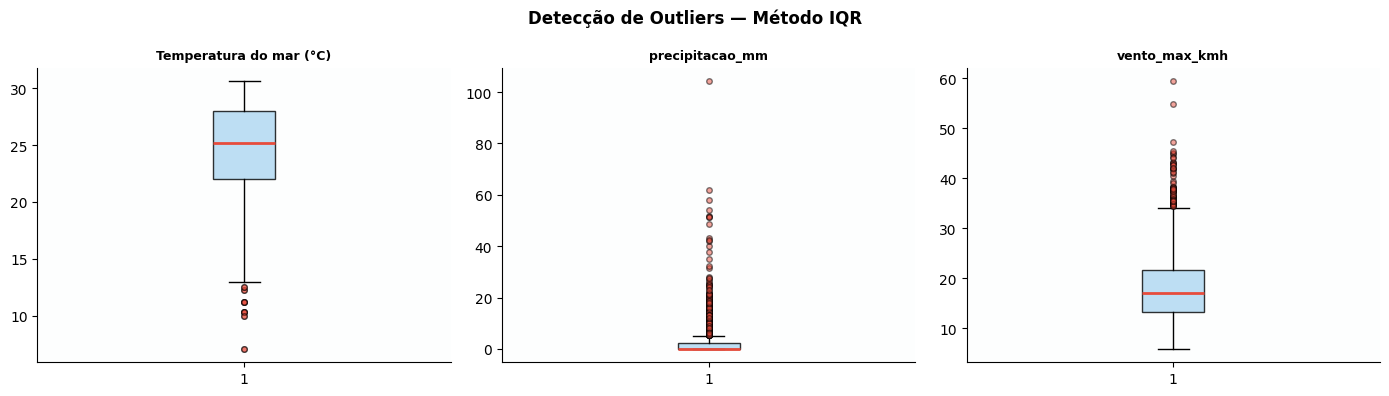

Total de outliers identificados: 355

Estratégia adotada: MANTER os outliers.
Justificativa: representam condições ambientais extremas reais
(ex: tempestades, ondas de calor) que são justamente os cenários
de maior risco de ataque — removê-los distorceria o modelo.


In [20]:
OUTLIER_COLS = ["Temperatura do mar (°C)", "precipitacao_mm", "vento_max_kmh"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Detecção de Outliers — Método IQR", fontsize=12, fontweight="bold")

total_outliers = 0
for i, col in enumerate(OUTLIER_COLS):
    serie = df_clean[col].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = int(((serie < lower) | (serie > upper)).sum())
    total_outliers += n_out

    print(f"{col}:")
    print(f"  Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}")
    print(f"  Limite inferior: {lower:.2f}  |  Superior: {upper:.2f}")
    print(f"  Outliers: {n_out} ({n_out/len(serie)*100:.1f}%)\n")

    axes[i].boxplot(serie, patch_artist=True,
                    boxprops=dict(facecolor="#AED6F1", alpha=0.8),
                    medianprops=dict(color="#E74C3C", linewidth=2),
                    flierprops=dict(marker="o", markersize=4,
                                    markerfacecolor="#E74C3C", alpha=0.5))
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].set_facecolor("#FDFEFE")
    axes[i].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Total de outliers identificados: {total_outliers}")
print("\nEstratégia adotada: MANTER os outliers.")
print("Justificativa: representam condições ambientais extremas reais")
print("(ex: tempestades, ondas de calor) que são justamente os cenários")
print("de maior risco de ataque — removê-los distorceria o modelo.")

In [21]:
# ---------------------------------------------------------------------------
# 3. HELPERS DE ESTILO
# ---------------------------------------------------------------------------

def style_ax(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8, color="#2C3E50")
    ax.set_xlabel(xlabel, fontsize=9, color="#5D6D7E")
    ax.set_ylabel(ylabel, fontsize=9, color="#5D6D7E")
    ax.set_facecolor(PALETTE["bg"])
    ax.grid(True, color=PALETTE["grid"], linewidth=0.7, linestyle="--", alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8, colors="#5D6D7E")


def add_note(ax, text):
    ax.text(
        0.01, -0.22, text,
        transform=ax.transAxes,
        fontsize=7.5, color="#5D6D7E",
        verticalalignment="top",
        wrap=True,
    )

In [22]:
# ---------------------------------------------------------------------------
# 4. VISUALIZAÇÕES
# ---------------------------------------------------------------------------

def plot_incidentes_por_pais(ax, df):
    """1. Distribuição absoluta de incidentes por país."""
    counts = df["Country"].value_counts()
    colors = [COUNTRY_COLORS.get(c, PALETTE["light"]) for c in counts.index]

    bars = ax.barh(counts.index[::-1], counts.values[::-1],
                   color=colors[::-1], edgecolor="white", height=0.6)

    for bar, val in zip(bars, counts.values[::-1]):
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
                f"{val}", va="center", fontsize=8.5, color="#2C3E50", fontweight="bold")

    ax.set_xlim(0, counts.max() * 1.15)
    style_ax(ax, "1. Incidentes por País", "Número de incidentes", "")
    add_note(ax, "EUA concentra 61% dos registros, seguido por Austrália (21%).\n"
                 "O Brasil representa apenas 4%, mas é relevante por ser o foco do sistema.")


def plot_evolucao_temporal(ax, df):
    """2. Evolução anual de incidentes (1980–2020)."""
    df_ano = df[(df["Year"] >= 1980) & (df["Year"] <= 2020)]
    por_ano = df_ano.groupby("Year").size().reset_index(name="count")

    ax.fill_between(por_ano["Year"], por_ano["count"],
                    alpha=0.18, color=PALETTE["primary"])
    ax.plot(por_ano["Year"], por_ano["count"],
            color=PALETTE["primary"], linewidth=2)

    # Destaque do pico
    pico = por_ano.loc[por_ano["count"].idxmax()]
    ax.scatter(pico["Year"], pico["count"],
               color=PALETTE["accent"], s=60, zorder=5)
    ax.annotate(f"Pico: {int(pico['Year'])} ({int(pico['count'])})",
                xy=(pico["Year"], pico["count"]),
                xytext=(pico["Year"] - 8, pico["count"] + 5),
                fontsize=7.5, color=PALETTE["accent"],
                arrowprops=dict(arrowstyle="->", color=PALETTE["accent"], lw=1))

    style_ax(ax, "2. Evolução Anual de Incidentes (1980–2020)",
             "Ano", "Número de incidentes")
    add_note(ax, "Tendência de crescimento de 1980 a 2015, com pico em 2015.\n"
                 "Queda em 2020 explicada pela pandemia (dados incompletos no período).")


def plot_atividades(ax, df):
    """3. Top 10 atividades com maior número de incidentes."""
    top = df["Activity"].value_counts().head(10)
    norm = top.values / top.values.max()
    colors = plt.cm.Blues(0.35 + 0.55 * norm)

    bars = ax.barh(top.index[::-1], top.values[::-1],
                   color=colors[::-1], edgecolor="white", height=0.65)

    for bar, val in zip(bars, top.values[::-1]):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                f"{val}", va="center", fontsize=8, color="#2C3E50")

    ax.set_xlim(0, top.max() * 1.15)
    style_ax(ax, "3. Atividades Mais Envolvidas em Ataques",
             "Número de incidentes", "")
    add_note(ax, "Surf lidera com 40% dos incidentes, coerente com maior exposição e\n"
                 "tempo passado na zona de arrebentação, área de caça de tubarões.")


def plot_gravidade(ax, df):
    """4. Gravidade dos ferimentos (Injury Category)."""
    order = ["Fatal", "Amputation / Severe", "Laceration",
             "Bite", "Minor Injury", "No Injury", "Unknown"]
    counts = df["Injury_category"].value_counts().reindex(order).dropna()

    pal = [PALETTE["accent"], "#C0392B", PALETTE["warn"],
           "#F8C471", PALETTE["success"], PALETTE["light"], "#BDC3C7"]

    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=None,
        colors=pal[:len(counts)],
        autopct="%1.1f%%",
        startangle=140,
        pctdistance=0.78,
        wedgeprops=dict(edgecolor="white", linewidth=1.2),
    )
    for at in autotexts:
        at.set_fontsize(7.5)

    ax.legend(counts.index, loc="lower left",
              fontsize=7, framealpha=0.8,
              bbox_to_anchor=(-0.05, -0.05))

    ax.set_title("4. Gravidade dos Ferimentos", fontsize=11,
                 fontweight="bold", pad=8, color="#2C3E50")
    add_note(ax, "Laceração (37%) e mordida (22%) dominam. Apenas 8,5% dos ataques\n"
                 "são fatais, indicando que a maioria é de baixa ou média gravidade.")


def plot_temperatura_por_pais(ax, df):
    """5. Distribuição da temperatura do mar por país (boxplot)."""
    col = "Temperatura do mar (°C)"
    df_clean = df[[col, "Country"]].dropna()

    order = df_clean.groupby("Country")[col].median().sort_values(ascending=False).index
    colors = [COUNTRY_COLORS.get(c, PALETTE["light"]) for c in order]

    bp = ax.boxplot(
        [df_clean[df_clean["Country"] == c][col].values for c in order],
        vert=True,
        patch_artist=True,
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker="o", markersize=3, alpha=0.4),
        widths=0.55,
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_xticks(range(1, len(order) + 1))
    ax.set_xticklabels([c.title() for c in order], fontsize=8, rotation=10)
    style_ax(ax, "5. Temperatura do Mar por País (°C)",
             "", "Temperatura (°C)")
    add_note(ax, "Brasil e México apresentam as temperaturas mais altas (>25°C),\n"
                 "favorecendo maior atividade de tubarões em águas quentes.")


def plot_correlacao(ax, df):
    """6. Heatmap de correlação entre variáveis ambientais."""
    cols = {
        "Temperatura do mar (°C)": "Temp. Mar",
        "temp_media_C":            "Temp. Ar",
        "precipitacao_mm":         "Precipit.",
        "vento_max_kmh":           "Vento",
        "umidade_max_pct":         "Umidade",
    }
    sub = df[list(cols.keys())].dropna()
    sub.columns = list(cols.values())
    corr = sub.corr()

    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(
        corr,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        linecolor="white",
        annot_kws={"size": 8},
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title("6. Correlação entre Variáveis Ambientais",
                 fontsize=11, fontweight="bold", pad=8, color="#2C3E50")
    ax.tick_params(labelsize=8)
    add_note(ax, "Forte correlação (0,77) entre temperatura do mar e temperatura do ar.\n"
                 "Vento correlaciona negativamente com umidade (-0,24): dias secos tendem a ser mais ventosos.")


def plot_fatal_por_pais(ax, df):
    """7. Proporção de incidentes fatais vs não fatais por país."""
    df_f = df[df["Fatal (Y/N)"].isin(["Y", "N"])].copy()
    df_f["fatal_label"] = df_f["Fatal (Y/N)"].map({"Y": "Fatal", "N": "Não fatal"})

    pivot = df_f.groupby(["Country", "fatal_label"]).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    pivot_pct = pivot_pct.reindex(
        df_f["Country"].value_counts().index
    )

    pivot_pct[["Não fatal", "Fatal"]].plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[PALETTE["light"], PALETTE["accent"]],
        edgecolor="white",
        width=0.55,
    )

    ax.set_xticklabels([c.title() for c in pivot_pct.index],
                       rotation=15, fontsize=8)
    ax.set_ylim(0, 108)
    ax.legend(["Não fatal", "Fatal"], fontsize=8, framealpha=0.8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    style_ax(ax, "7. Proporção Fatal vs Não Fatal por País",
             "", "% dos incidentes")
    add_note(ax, "Austrália apresenta a maior taxa de fatalidade (~12%), seguida por\n"
                 "África do Sul. EUA tem a menor proporção apesar do maior volume.")


In [23]:
# ---------------------------------------------------------------------------
# 5. FIGURA PRINCIPAL
# ---------------------------------------------------------------------------

def main():
    print("Carregando e limpando dados...")
    df = load_and_clean()

    print_descriptive_stats(df)

    print("Gerando visualizações...")
    fig = plt.figure(figsize=(20, 22))
    fig.patch.set_facecolor(PALETTE["bg"])

    fig.suptitle(
        "Análise Exploratória de Dados — Ataques de Tubarão\n"
        "DeepSearch · CESAR School · Machine Learning I 2026.1",
        fontsize=15, fontweight="bold", color="#1B2631", y=0.99,
    )

    gs = gridspec.GridSpec(
        4, 2, figure=fig,
        hspace=0.72, wspace=0.35,
        left=0.07, right=0.96, top=0.96, bottom=0.04,
    )

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])
    ax5 = fig.add_subplot(gs[2, 0])
    ax6 = fig.add_subplot(gs[2, 1])
    ax7 = fig.add_subplot(gs[3, :])

    plot_incidentes_por_pais(ax1, df)
    plot_evolucao_temporal(ax2, df)
    plot_atividades(ax3, df)
    plot_gravidade(ax4, df)
    plot_temperatura_por_pais(ax5, df)
    plot_correlacao(ax6, df)
    plot_fatal_por_pais(ax7, df)

    fig.savefig(OUTPUT_PATH, dpi=150, bbox_inches="tight",
                facecolor=PALETTE["bg"])
    print(f"\nFigura salva em: {OUTPUT_PATH}")


Carregando e limpando dados...
ESTATÍSTICAS DESCRITIVAS — DeepSearch EDA
Total de registros : 2559
Total de colunas   : 41
Período coberto    : 1980 – 2020
Países             : 5 (USA, AUSTRALIA, SOUTH AFRICA, MEXICO, BRAZIL)

--- Valores nulos (colunas relevantes) ---
  Date                          :  160 nulos (6.3%)
  Year                          :    0 nulos (0.0%)
  Country                       :    0 nulos (0.0%)
  Activity                      :    0 nulos (0.0%)
  Fatal (Y/N)                   :  188 nulos (7.3%)
  Age                           :  665 nulos (26.0%)
  Time                          :  728 nulos (28.4%)
  Injury_category               :    0 nulos (0.0%)
  Temperatura do mar (°C)       :    0 nulos (0.0%)
  temp_media_C                  :  289 nulos (11.3%)
  precipitacao_mm               :  289 nulos (11.3%)
  vento_max_kmh                 :  289 nulos (11.3%)

--- Estatísticas das variáveis ambientais numéricas ---
       Temperatura do mar (°C)  temp_media_C

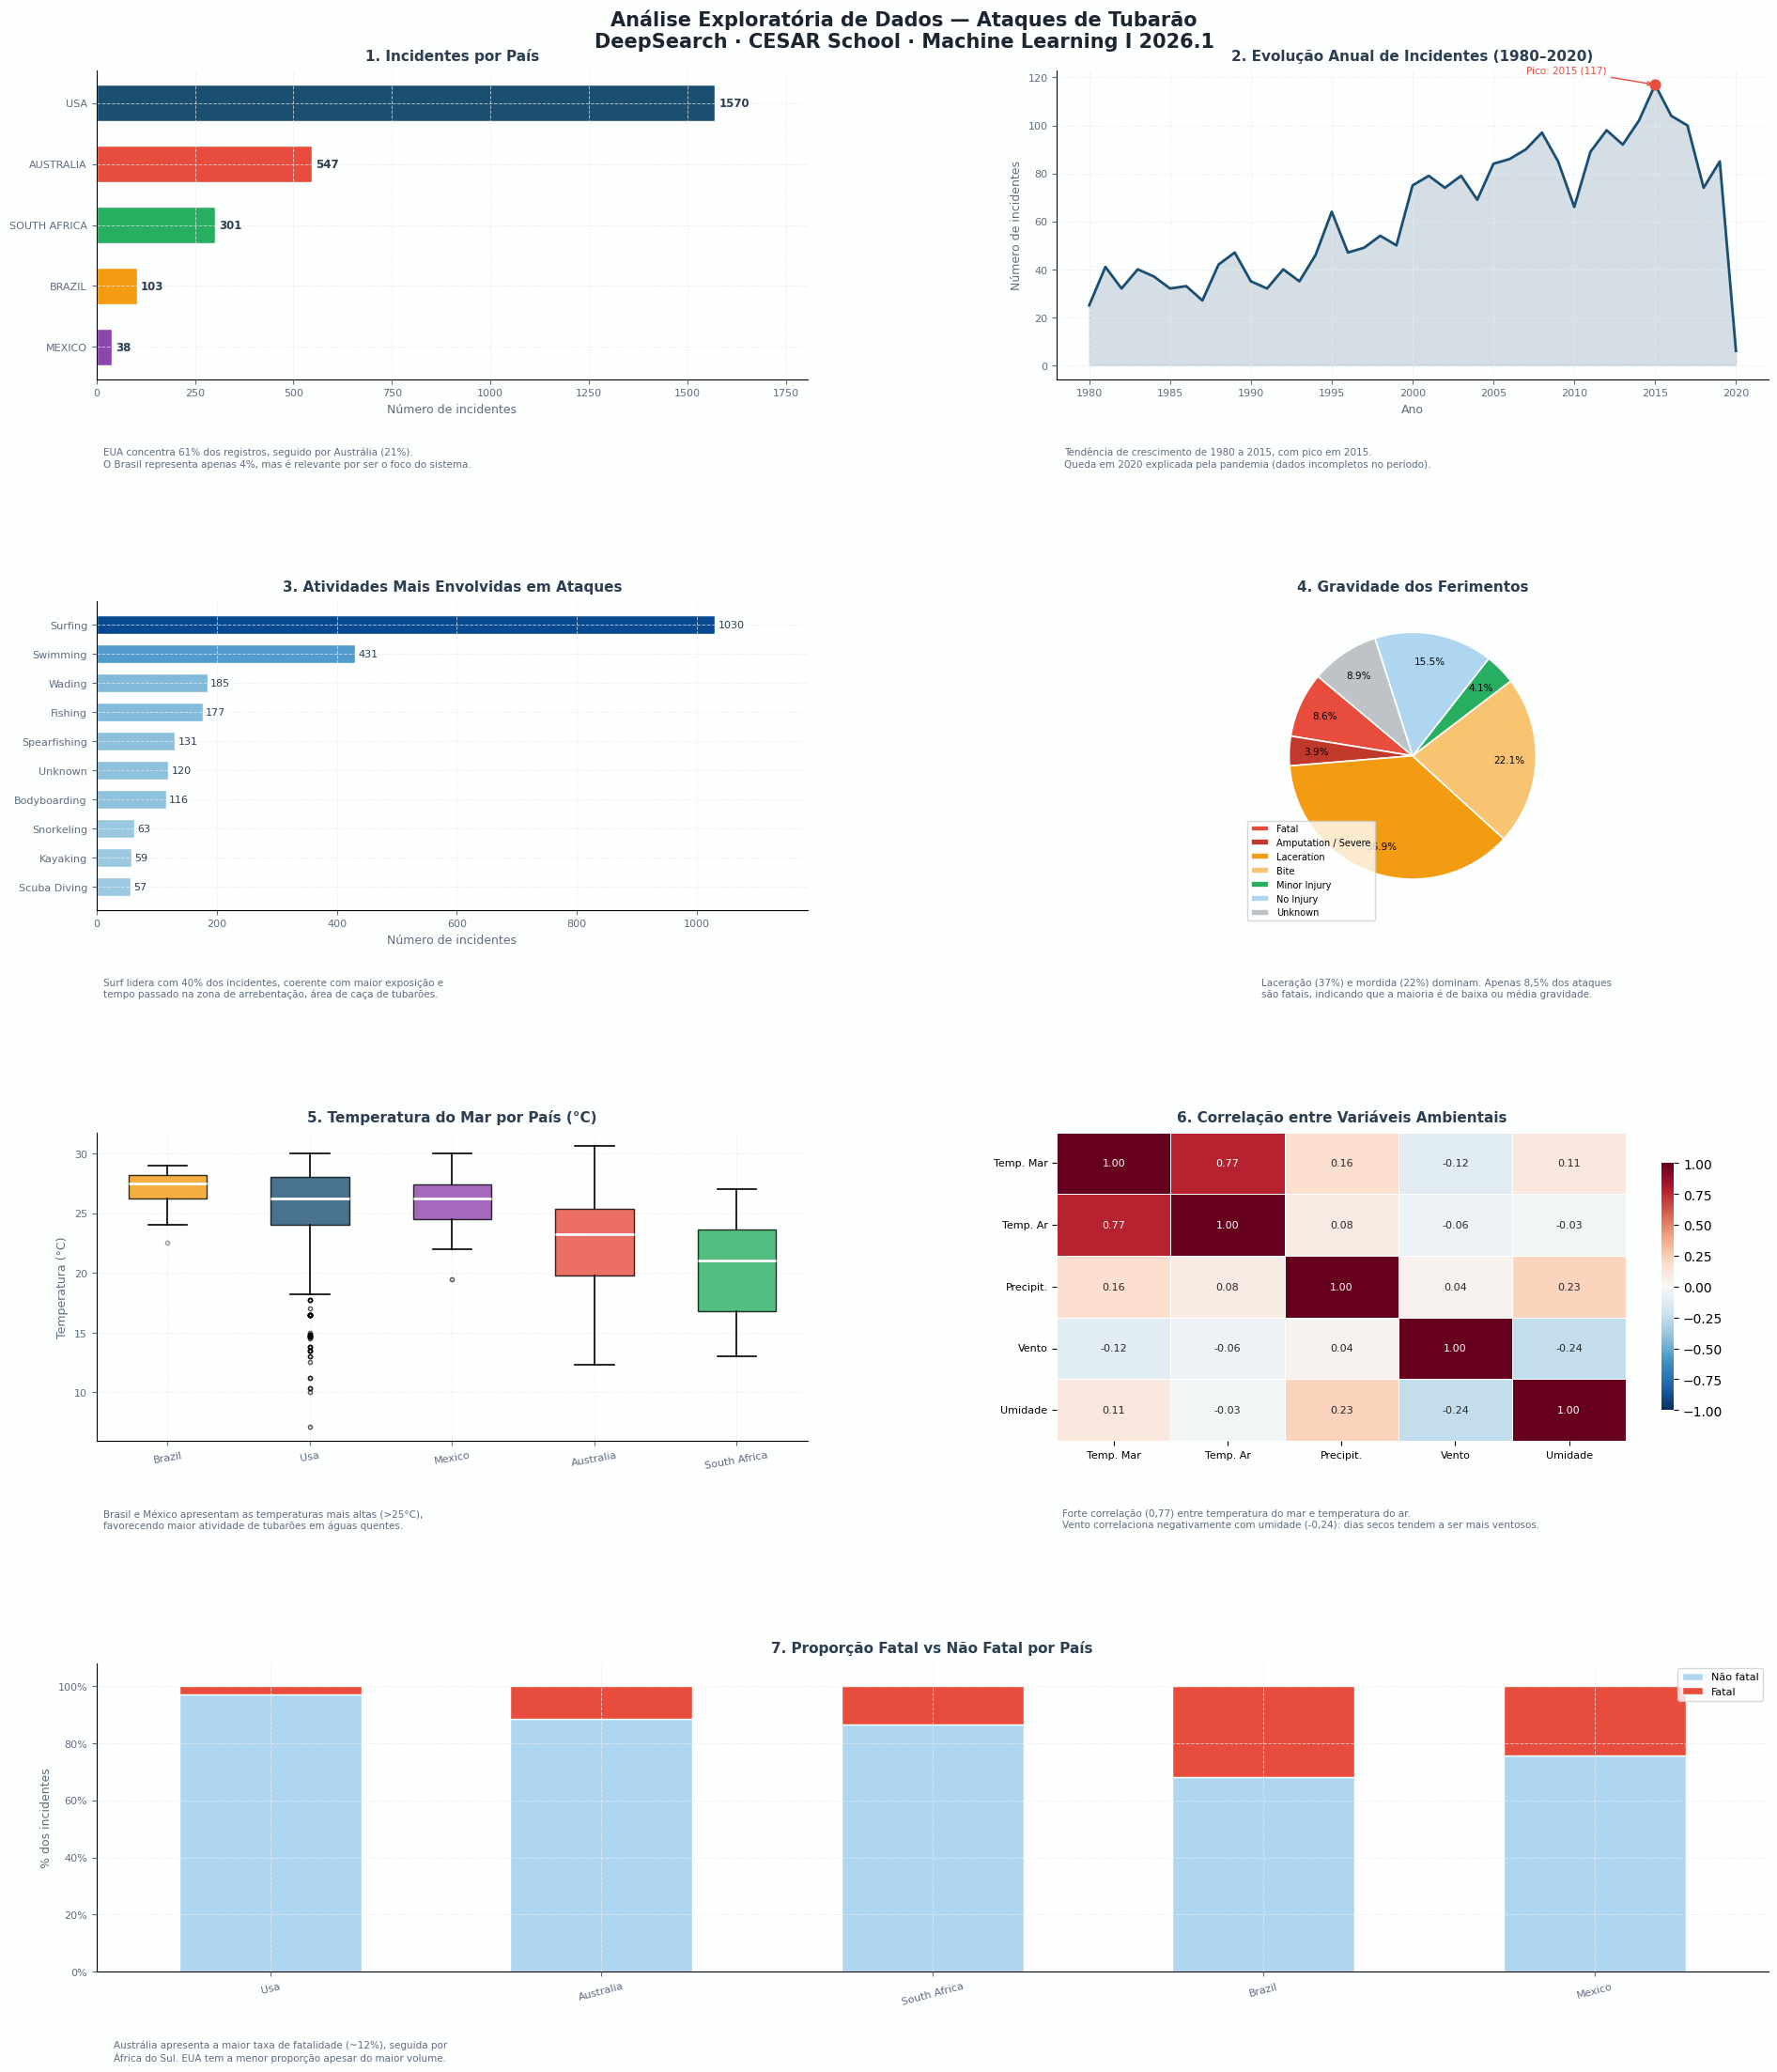

In [24]:
main()
plt.show()